In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer
import glob

sns.set_theme()

In [173]:
files = glob.glob("../data/*.csv")
file_list = [ pd.read_csv(file) for file in files ]

In [174]:
data = pd.concat(file_list, axis=0, ignore_index=True)
data

,COMMENT_ID,AUTHOR,DATE,CONTENT,CLASS
0,z13uwn2heqndtr5g304ccv5j5kqqzxjadmc0k,Corey Wilson,2015-05-28T21:39:52.376000,"<a href=""http://www.youtube.com/watch?v=KQ6zr6...",0
1,z124jvczaz3dxhnbc04cffk43oiugj25yzo0k,Epic Gaming,2015-05-28T20:07:20.610000,wierd but funny﻿,0
2,z13tczjy5xj0vjmu5231unho1ofey5zdk,LaS Music,2015-05-28T19:23:35.355000,"Hey guys, I&#39;m a human.<br /><br /><br />Bu...",1
3,z13tzr0hdpnayhqqc04cd3zqqqjkf3ngckk0k,Cheryl Fox,2015-05-28T17:49:35.294000,Party Rock....lol...who wants to shuffle!!!﻿,0
4,z12pcvix4zedcjvyb04ccr1r0mr2g5xwyng0k,PATRICK_TW,2015-05-28T16:28:26.818000,Party rock﻿,0
...,...,...,...,...,...
1950,LneaDw26bFu3RCmyrWyP9S6wh1h9dBv3X95g1HzKAb4,Dany PK,NaN,SUBSCRIBE TO MY CHANNEL X PLEASE!. SPARE,1
1951,LneaDw26bFsD65dtIvAEObWYIYnFTqQDKBek_Ypz3J8,SmexyFriedChicken,NaN,Check out my videos guy! :) Hope you guys had ...,1
1952,LneaDw26bFuvs-8oWkLpAFa6g3QHpWD8k7sbbMP3Bg8,The Guy That's Done Everything,NaN,3 yrs ago I had a health scare but thankfully ...,1
1953,z12hfp2wmyuqztkw504cgblyxtbsxjuzeow0k,Jesse Pinkman,2015-05-06T11:42:44.601000,Rihanna looks so beautiful with red hair ;)﻿,0


In [175]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1955 entries, 0 to 1954
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   COMMENT_ID  1955 non-null   str  
 1   AUTHOR      1955 non-null   str  
 2   DATE        1710 non-null   str  
 3   CONTENT     1955 non-null   str  
 4   CLASS       1955 non-null   int64
dtypes: int64(1), str(4)
memory usage: 76.5 KB


In [176]:
data.drop(columns={"COMMENT_ID", "AUTHOR", "DATE"}, inplace=True)
data

,CONTENT,CLASS
0,"<a href=""http://www.youtube.com/watch?v=KQ6zr6...",0
1,wierd but funny﻿,0
2,"Hey guys, I&#39;m a human.<br /><br /><br />Bu...",1
3,Party Rock....lol...who wants to shuffle!!!﻿,0
4,Party rock﻿,0
...,...,...
1950,SUBSCRIBE TO MY CHANNEL X PLEASE!. SPARE,1
1951,Check out my videos guy! :) Hope you guys had ...,1
1952,3 yrs ago I had a health scare but thankfully ...,1
1953,Rihanna looks so beautiful with red hair ;)﻿,0


In [177]:
train_data, test_data = train_test_split(data, test_size=0.25, random_state=42, shuffle=True)

In [178]:
converter = CountVectorizer().fit(train_data["CONTENT"])
x_train = converter.transform(train_data["CONTENT"])
y_train = train_data["CLASS"]

x_test = converter.transform(test_data["CONTENT"])
y_test = test_data["CLASS"]

In [179]:
ratios = y_train.value_counts(normalize=True)
ratios

CLASS
1    0.507503
0    0.492497
Name: proportion, dtype: float64

In [180]:
model = MultinomialNB(fit_prior=False).fit(x_train, y_train)

              precision    recall  f1-score   support

           0       0.96      0.93      0.94       229
           1       0.94      0.97      0.95       260

    accuracy                           0.95       489
   macro avg       0.95      0.95      0.95       489
weighted avg       0.95      0.95      0.95       489



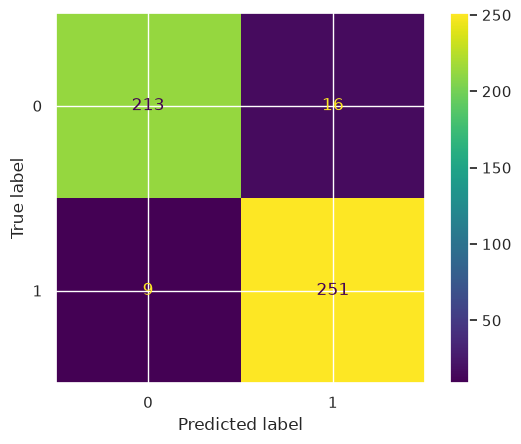

In [181]:
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()